In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time as time
from IPython.display import clear_output
from tqdm import trange

In [3]:
BOARD_SIZE = 5
GAMMA = 0.9
EPOCHS = 10000
EVAL_EPOCHS = 10000

## Environment
This time, we will use the competition environment, the one where each cell has either vertical or horizontal wind, with more strength in one direction

In [4]:
class Environment:
    def __init__(self, size=BOARD_SIZE):
        self.x = 0
        self.y = 0
        self.size = size
        self.goal_x = size - 1
        self.goal_y = size - 1
        self.steps = 0

    def windX(self, action):
        return 0
    def windY(self, action):
        return 0

    def move(self, action):
        self.steps += 1
        if self.steps > 50:
            return -1, True
        dx = 0 if action == "up" or action == "down" else 1 if action == "right" else -1
        dy = 0 if action == "left" or action == "right" else 1 if action == "up" else -1

        dx += self.windX(action)
        dy += self.windY(action)

        self.x = self.x + dx
        self.y = self.y + dy

        hit_wall = self.x < 0 or self.x >= self.size or self.y < 0 or self.y >= self.size

        self.x = min(max(0, self.x), self.size - 1)
        self.y = min(max(0, self.y), self.size - 1)

        done = self.x == self.goal_x and self.y == self.goal_y

        reward = 0 if not done else 1
        reward -= hit_wall * 0.1

        return reward, done

    def reset(self):
        self.x = 0
        self.y = 0
        self.steps = 0

# windy environment of the competition
class CompetitionEnvironment(Environment):
    def __init__(self, size=BOARD_SIZE, prob=0.9):
        super().__init__(size)
        self.prob=prob

    def windX(self, action):
        return {
            0: {
                0: np.random.choice([-2, -1, 1]),
                1: 0
            },
            1: {
                1: np.random.choice([-1, 1, 2]),
                0: 0
            }
        }[self.y%2][self.x%2]

    def windY(self, action):
        return {
            0: {
                1: np.random.choice([-2, -1, 1]),
                0: 0
            },
            1: {
                0: np.random.choice([-1, 1, 2]),
                1: 0
            }
        }[self.x%2][self.y%2]

In [5]:
# quick estimate of the return of a rollout
def compute_return(rewards, gamma=GAMMA):
    assert len(np.shape(gamma**np.arange(len(rewards))*rewards)) == 1, np.shape(gamma**np.arange(len(rewards))*rewards)
    return np.sum(gamma**np.arange(len(rewards))*rewards)

# smoothing for plots purposes
def smooth_variable_window(arr, window_size=10):
    smoothed_arr = np.zeros_like(arr, dtype=float)
    for i in range(len(arr)):
        half_window = window_size
        start = max(0, i - half_window)
        end = min(len(arr), i + half_window + 1)
        smoothed_arr[i] = np.mean(arr[start:end])
    return smoothed_arr

# evaluate a policy in the competition environment for many times, for accurate estimation
def evaluate_policy(policy, runs=EVAL_EPOCHS):
    returns = []
    for _ in trange(runs):
        rewards = []
        env = CompetitionEnvironment()
        while True:
            x, y = env.x, env.y
            action = policy.greedy_act(x, y)
            reward, done = env.move(action)
            rewards.append(reward)
            if done:
                env.reset()
                break
        returns.append(compute_return(rewards))
    return np.mean(returns), np.std(returns)

## Q-learning
Here we will define the code for Q-learning, with two different settings:
 - "Plain" $\epsilon$-greedy Q-learning: we apply Q learning, but the action is chosen accordingly to an $\epsilon$-greed policy
 - "Smart" $\epsilon$-greedy Q-learning: we apply Q learning, but the $\epsilon$ decays over time

In [6]:
# base class, nothing special
class QTable:
    def __init__(self, size=BOARD_SIZE, actions=4, gamma=GAMMA):
        self.q_values = np.zeros((size, size, actions))
        self.counts = np.zeros((size, size, actions))
        self.gamma = gamma
        self.size = size
    def update(self, SARS):
        raise NotImplementedError()

    def greedy_act(self, x, y):
        return self.to_action(np.argmax(self.q_values[y, x]))

    def draw(self):
        fig, ax = plt.subplots()
        # Create a color map based on the value grid
        values = np.max(self.q_values, axis=2)  # Assuming values are max Q-values for coloring
        cax = ax.imshow(values, cmap='coolwarm', origin='lower', extent=[0, self.size, 0, self.size])

        # Add a color bar to indicate value levels
        fig.colorbar(cax)

        # Draw grid lines
        ax.grid(which='both', color='black', linestyle='-', linewidth=0.5)
        ax.set_xticks(np.arange(0, self.size, 1))
        ax.set_yticks(np.arange(0, self.size, 1))

        # Drawing arrows for Q-values
        for i in range(self.size):
            for j in range(self.size):
                min_value = np.min(self.q_values[j, i])
                q_values = self.q_values[j, i] - min_value
                q_values += 1e-4
                max_value = np.max(q_values)+1e-8
                q_values /= max_value
                for action in range(4):
                    if action == 0:  # up
                        dx, dy = 0, 0.1
                    elif action == 1:  # down
                        dx, dy = 0, -0.1
                    elif action == 2:  # left
                        dx, dy = -0.1, 0
                    elif action == 3:  # right
                        dx, dy = 0.1, 0

                    q_value = q_values[action]*1.5
                    ax.arrow(i + 0.5, j + 0.5, dx * q_value  , dy * q_value ,
                             head_width=0.05, head_length=0.1, fc='k', ec='k')

        # Set limits and grid settings
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        plt.show()
    def draw_policy(self):
        fig, ax = plt.subplots()
        # Create a color map based on the value grid
        values = np.max(self.q_values, axis=2)  # Assuming values are max Q-values for coloring
        cax = ax.imshow(values, cmap='coolwarm', origin='lower', extent=[0, self.size, 0, self.size])

        # Add a color bar to indicate value levels
        fig.colorbar(cax)

        # Draw grid lines
        ax.grid(which='both', color='black', linestyle='-', linewidth=0.5)
        ax.set_xticks(np.arange(0, self.size, 1))
        ax.set_yticks(np.arange(0, self.size, 1))

        # Drawing arrows for the policy derived from Q-values
        for i in range(self.size):
            for j in range(self.size):
                best_action = np.argmax(self.q_values[j, i])
                if best_action == 0:  # up
                    dx, dy = 0, 0.2
                elif best_action == 1:  # down
                    dx, dy = 0, -0.2
                elif best_action == 2:  # left
                    dx, dy = -0.2, 0
                elif best_action == 3:  # right
                    dx, dy = 0.2, 0

                ax.arrow(i + 0.5, j + 0.5, dx, dy, head_width=0.1, head_length=0.1, fc='k', ec='k')

        # Set limits and grid settings
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        plt.show()
    def to_index(self, a):
            return {
            "up": 0,
            "down": 1,
            "left": 2,
            "right": 3
        }[a]
    def to_action(self, a):
        return ["up", "down", "left", "right"][a]

## Example using MC Control and eps-greedy

In [7]:
# Q-learning using full monte carlo instead of temporal difference
class MonteCarloControl(QTable):
    def __init__(self, size=BOARD_SIZE, actions=4, gamma=0.9, epsilon=0.1):
        super().__init__(size, actions, gamma)
        self.epsilon = epsilon
    def update(self, SARS):
        states = [s for s, _, _, _ in SARS][::-1]
        actions = [a for _, a, _, _ in SARS][::-1]
        rewards = [r for _, _, r, _ in SARS][::-1]
        returns = 0
        for i in range(len(SARS)):
            returns = rewards[i] + self.gamma * returns
            x, y = states[i]
            action = self.to_index(actions[i])
            self.q_values[y, x, action] = (returns + self.q_values[y, x, action] * self.counts[y, x, action]) / (self.counts[y, x, action] + 1)
            self.counts[y, x, action] += 1


    def act(self, x, y):
        if np.random.rand() < self.epsilon:
            return self.to_action(np.random.choice([0, 1, 2, 3]))
        return self.to_action(np.argmax(self.q_values[y, x]))

In [8]:
env = CompetitionEnvironment()
policy = MonteCarloControl()
EPS = []
GREEDY_REWARDS = []
for _ in trange(EPOCHS):
    sars = []
    while True:
        x, y = env.x, env.y
        action = policy.act(x, y)
        reward, done = env.move(action)
        sars.append(((x, y), action, reward, (env.x, env.y)))
        if done:
            env.reset()
            break
    EPS.append(policy.epsilon)

    GREEDY_REWARDS.append([])
    while True:
        x, y = env.x, env.y
        action = policy.greedy_act(x, y)
        reward, done = env.move(action)
        GREEDY_REWARDS[-1].append(reward)
        if done:
            env.reset()
            break
    GREEDY_REWARDS[-1] = compute_return(GREEDY_REWARDS[-1])
    policy.update(sars)

100%|██████████| 10000/10000 [00:16<00:00, 602.04it/s]


100%|██████████| 10000/10000 [00:06<00:00, 1570.50it/s]


policy performance: mean: 0.3627959588753909 std: 0.20450951131680103


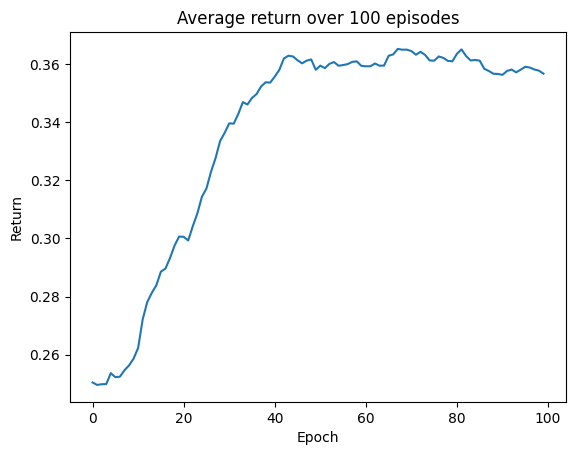

In [9]:
plt.plot(smooth_variable_window(np.array(GREEDY_REWARDS).reshape((-1,100)).mean(axis=-1)))
plt.title("Average return over 100 episodes")
plt.xlabel("Epoch")
plt.ylabel("Return")

mean, std = evaluate_policy(policy)
print("policy performance: mean:", mean, "std:", std)

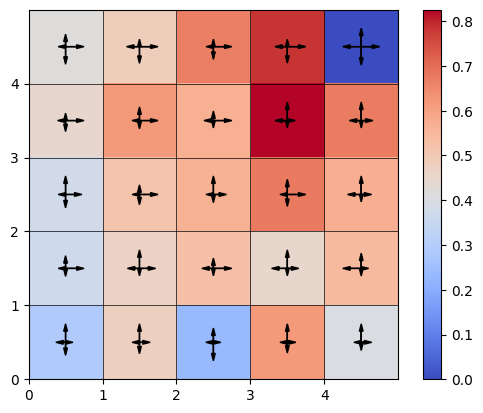

In [10]:
# visualize the Q-values
policy.draw()

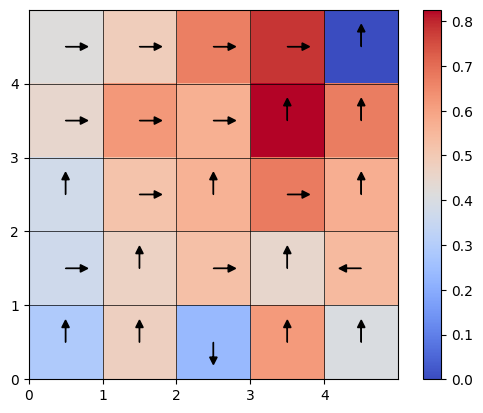

In [11]:
# visualize the greedy policy
policy.draw_policy()

## Example using Q-learning with fixed exploration

In [12]:
# Q-learning with fixed epsilon
class QLearning(QTable):
    def __init__(self, size=BOARD_SIZE, actions=4, gamma=0.9, epsilon=0.1):
        super().__init__(size, actions, gamma)
        self.epsilon = epsilon
    def update(self, SARS):
        # SARS = array of (state, action, reward, next_state)
        for state, action, reward, next_state in SARS:
            x, y = state
            next_x, next_y = next_state
            action = self.to_index(action)
            self.q_values[y, x, action] = (reward + self.gamma * np.max(self.q_values[next_y, next_x]) + self.q_values[y, x, action] * self.counts[y, x, action]) / (self.counts[y, x, action] + 1)
            self.counts[y, x, action] += 1

    def act(self, x, y):
        if np.random.rand() < self.epsilon:
            return self.to_action(np.random.choice([0, 1, 2, 3]))
        return self.to_action(np.argmax(self.q_values[y, x]))


# Q-learning with random policy for exploration
class RandomQLearning(QLearning):
    def act(self, x, y):
        return self.to_action(np.random.choice([0, 1, 2, 3]))

# Q-learning with decaying epsilon
class SmartQLearning(QLearning):
    def __init__(self, size=BOARD_SIZE, actions=4, gamma=0.9, epsilon=0.1, decay=0.999):
        super().__init__(size, actions, gamma)
        self.epsilon = epsilon
        self.decay = decay
    def update(self, SARS):
        self.epsilon *= self.decay
        super().update(SARS)

In [13]:
env = CompetitionEnvironment()
policy = QLearning()
EPS = []
GREEDY_REWARDS = []
for _ in trange(EPOCHS):

    while True:
        x, y = env.x, env.y
        action = policy.act(x, y)
        reward, done = env.move(action)
        policy.update([((x, y), action, reward, (env.x, env.y))])
        if done:
            env.reset()
            break
    EPS.append(policy.epsilon)

    GREEDY_REWARDS.append([])
    while True:
        x, y = env.x, env.y
        action = policy.greedy_act(x, y)
        reward, done = env.move(action)
        GREEDY_REWARDS[-1].append(reward)
        if done:
            env.reset()
            break
    GREEDY_REWARDS[-1] = compute_return(GREEDY_REWARDS[-1])


100%|██████████| 10000/10000 [00:15<00:00, 641.53it/s]


100%|██████████| 10000/10000 [00:06<00:00, 1558.98it/s]


policy performance: mean: 0.35984679131872443 std: 0.2088782218109295


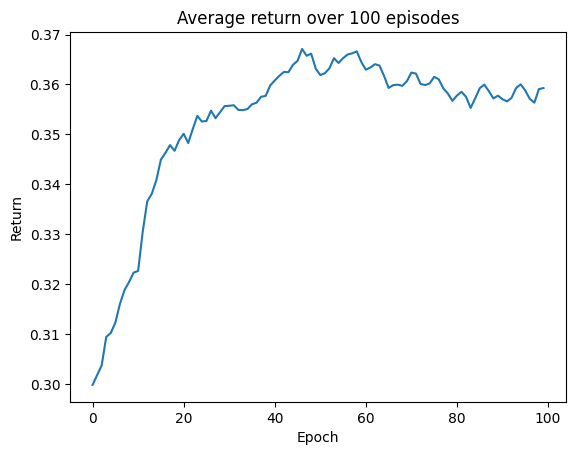

In [14]:
plt.plot(smooth_variable_window(np.array(GREEDY_REWARDS).reshape((-1,100)).mean(axis=-1)))
plt.title("Average return over 100 episodes")
plt.xlabel("Epoch")
plt.ylabel("Return")

mean, std = evaluate_policy(policy)
print("policy performance: mean:", mean, "std:", std)

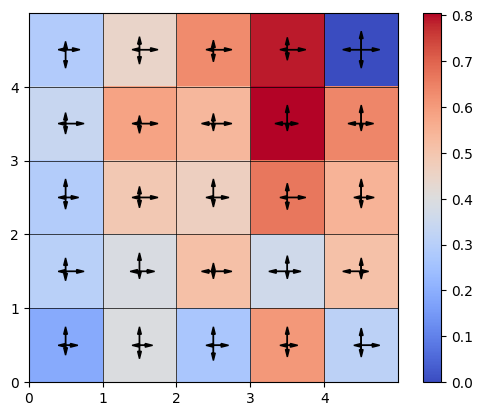

In [15]:
# visualize the Q-values
policy.draw()

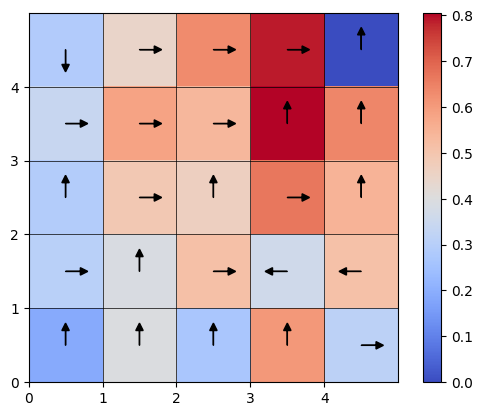

In [16]:
# visualize the greedy policy
policy.draw_policy()

## Example using Q-learning and uniform random behavioural policy

In [17]:
env = CompetitionEnvironment()
policy = RandomQLearning()
EPS = []
GREEDY_REWARDS = []
for _ in trange(EPOCHS):
    while True:
        x, y = env.x, env.y
        action = policy.act(x, y)
        reward, done = env.move(action)
        policy.update([((x, y), action, reward, (env.x, env.y))])
        if done:
            env.reset()
            break
    EPS.append(policy.epsilon)

    GREEDY_REWARDS.append([])
    while True:
        x, y = env.x, env.y
        action = policy.greedy_act(x, y)
        reward, done = env.move(action)
        GREEDY_REWARDS[-1].append(reward)
        if done:
            env.reset()
            break
    GREEDY_REWARDS[-1] = compute_return(GREEDY_REWARDS[-1])

100%|██████████| 10000/10000 [00:42<00:00, 236.72it/s]


100%|██████████| 10000/10000 [00:06<00:00, 1570.96it/s]


policy performance: mean: 0.3636841598248415 std: 0.20503211057667045


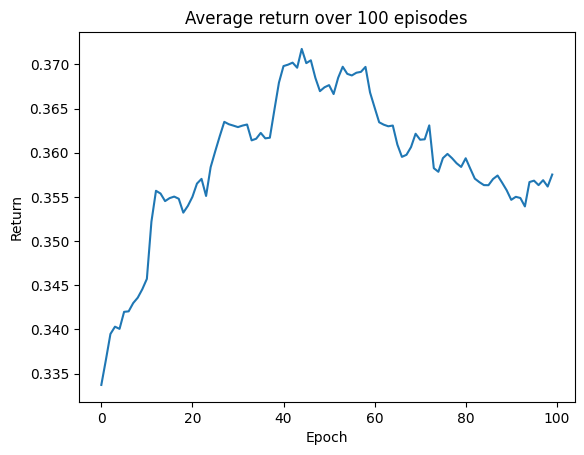

In [18]:
plt.plot(smooth_variable_window(np.array(GREEDY_REWARDS).reshape((-1,100)).mean(axis=-1)))
plt.title("Average return over 100 episodes")
plt.xlabel("Epoch")
plt.ylabel("Return")

mean, std = evaluate_policy(policy)
print("policy performance: mean:", mean, "std:", std)

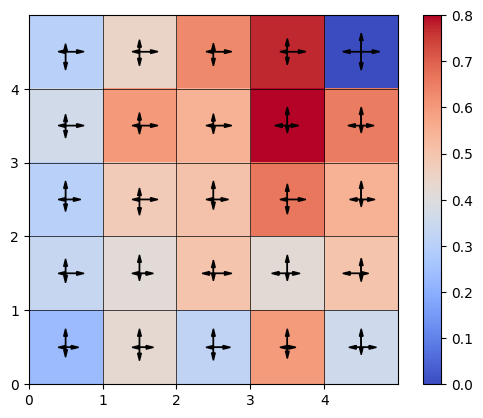

In [19]:
# visualize the Q-values
policy.draw()

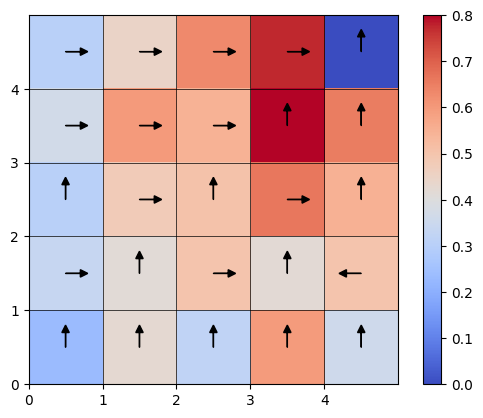

In [20]:
# visualize the greedy policy
policy.draw_policy()

## Examples using a decaying exploration factor

In [21]:
DECAYS = [0.99,0.999, 0.9999]

In [22]:
hist = {}
for decay in DECAYS:
    env = CompetitionEnvironment()
    policy = SmartQLearning(decay=decay)
    EPS = []
    REWARDS = []
    GREEDY_REWARDS = []
    for _ in trange(EPOCHS):
        REWARDS.append([])
        GREEDY_REWARDS.append([])
        while True:
            x, y = env.x, env.y
            action = policy.act(x, y)
            reward, done = env.move(action)
            REWARDS[-1].append(reward)
            policy.update([((x, y), action, reward, (env.x, env.y))])
            if done:
                env.reset()
                break
        EPS.append(policy.epsilon)
        REWARDS[-1] = compute_return(REWARDS[-1])

        while True:
            x, y = env.x, env.y
            action = policy.greedy_act(x, y)
            reward, done = env.move(action)
            GREEDY_REWARDS[-1].append(reward)
            if done:
                env.reset()
                break
        GREEDY_REWARDS[-1] = compute_return(GREEDY_REWARDS[-1])
        policy.update(sars)

    hist[decay] = [EPS, policy, REWARDS, GREEDY_REWARDS]

100%|██████████| 10000/10000 [00:15<00:00, 653.56it/s]


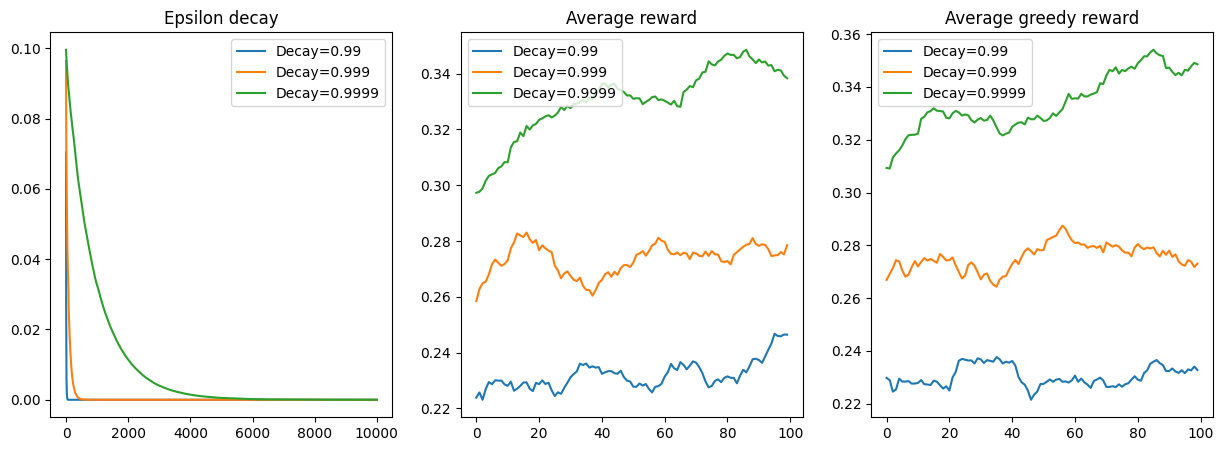

In [23]:
fig,ax= plt.subplots(1,3, figsize=(15,5))
for decay in DECAYS:
    ax[0].plot(hist[decay][0], label=f"Decay={decay}")
    ax[1].plot(smooth_variable_window(np.array(hist[decay][2]).reshape((-1,100)).mean(axis=-1)), label=f"Decay={decay}")
    ax[2].plot(smooth_variable_window(np.array(hist[decay][3]).reshape((-1,100)).mean(axis=-1)), label=f"Decay={decay}")

    ax[0].set_title("Epsilon decay")
    ax[1].set_title("Average reward")
    ax[2].set_title("Average greedy reward")
    ax[0].legend()
    ax[1].legend()
    ax[2].legend()

In [24]:
for decay in DECAYS:
    mean, std = evaluate_policy(hist[decay][1])
    print(f"policy {decay} performance: mean:", mean, "std:", std)

100%|██████████| 10000/10000 [00:10<00:00, 932.12it/s]


policy 0.99 performance: mean: 0.22774565952753584 std: 0.246562453707488


100%|██████████| 10000/10000 [00:08<00:00, 1207.12it/s]


policy 0.999 performance: mean: 0.27653811857272514 std: 0.2497760567847037


100%|██████████| 10000/10000 [00:05<00:00, 1698.17it/s]

policy 0.9999 performance: mean: 0.3481422176355914 std: 0.18248755253876373


## Your turn: Expected Sarsa

In [25]:
# Q-learning with fixed epsilon
class ExpectedSarsa(QTable):
    def __init__(self, size=BOARD_SIZE, actions=4, gamma=0.9, epsilon=0.1):
        super().__init__(size, actions, gamma)
        self.epsilon = epsilon
    def update(self, SARS):
        # SARS = array of (state, action, reward, next_state)
        for state, action, reward, next_state in SARS:
            x, y = state
            next_x, next_y = next_state
            action = self.to_index(action)
            self.q_values[y, x, action] = (reward + self.gamma/4 * np.sum(self.q_values[next_y, next_x]) + self.q_values[y, x, action] * self.counts[y, x, action]) / (self.counts[y, x, action] + 1)## Update here with your expected sarsa implementation
            self.counts[y, x, action] += 1

    def act(self, x, y):
        if np.random.rand() < self.epsilon:
            return self.to_action(np.random.choice([0, 1, 2, 3]))
        return self.to_action(np.argmax(self.q_values[y, x]))

In [26]:
env = CompetitionEnvironment()
policy = ExpectedSarsa()
EPS = []
GREEDY_REWARDS = []
for _ in trange(EPOCHS):
    while True:
        x, y = env.x, env.y
        action = policy.act(x, y)
        reward, done = env.move(action)
        policy.update([((x, y), action, reward, (env.x, env.y))])
        if done:
            env.reset()
            break
    EPS.append(policy.epsilon)

    GREEDY_REWARDS.append([])
    while True:
        x, y = env.x, env.y
        action = policy.greedy_act(x, y)
        reward, done = env.move(action)
        GREEDY_REWARDS[-1].append(reward)
        if done:
            env.reset()
            break
    GREEDY_REWARDS[-1] = compute_return(GREEDY_REWARDS[-1])

100%|██████████| 10000/10000 [00:15<00:00, 652.62it/s]


100%|██████████| 10000/10000 [00:06<00:00, 1638.24it/s]


policy performance: mean: 0.35665488839502607 std: 0.20729170136487385


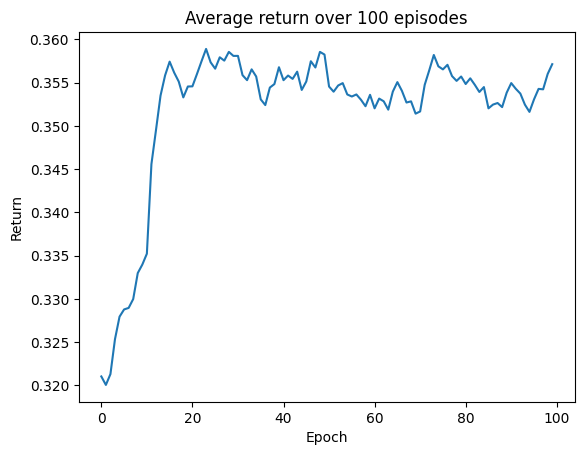

In [28]:
plt.plot(smooth_variable_window(np.array(GREEDY_REWARDS).reshape((-1,100)).mean(axis=-1)))
plt.title("Average return over 100 episodes")
plt.xlabel("Epoch")
plt.ylabel("Return")

mean, std = evaluate_policy(policy)
print("policy performance: mean:", mean, "std:", std)